### Some Tweaks

### Note to Dean

Dean, thanks for the really nice work on this example.
I made some adjustments in the scaling of shocks.  I explain how I (tried to) introduce some orthogonalizations
into the impulse response functions.  

You'll see what I did at the points in the code that construct the impulse response functions.

I'll probably want to fine tune the graphs a little -- e.g., add some captions beneath each graph. Maybe we can talk about how to do that in a few days. 



### Implied Vector Autoregression

We want to tweak the moving average innovations representation
that emerges from the time-invariant Kalman filter, namely,

$$
y_t = [I + G (I - A \tilde L)^{-1} K \tilde L ] a_t
$$

where $\tilde L$ is the lag operator and $E a_t a_t = \Omega$ is the innovation covariance matrix computed from

$$
\Omega = G \Sigma_\infty G' + R
$$

We'll construct a Cholesky decomposion

$$ 
L L^\top  = \Omega
$$

where $L$ is lower triangular and define $u_t$ by 

$$
L u_t = a_t 
$$

where 

$$ 
E u_t u_t^\top = I
$$

We can then write the innovations representation in terms of orthogonalized innovations $u_t$ as


$$
y_t = [I + G (I - A \tilde L)^{-1} K \tilde L ] L u_t
$$

Notice how $Lu_t = a_t$ let's the first component $a_{1t}$ 
of $a_t$ go first in the orthogonalization.

To construct an alternative orthogonalization that lets $a_{2t}$ go first let $F$ be the permutation matrix

$$
F = \begin{bmatrix} 0 & 1 \cr 1 & 0 \end{bmatrix}
$$

that validates

$$ \begin{bmatrix} a_{2t} \cr a_{1t} \end{bmatrix}
= F \begin{bmatrix} a_{1t} \cr a_{2t} \end{bmatrix}
$$

and  construct the flipped covariance matrix

$$
\Omega_f = F \Omega F^\top
$$ 

Construct a lower-triangular Cholesky decomposition of
$\Omega_f$:

$$
S S^\top = \Omega_f
$$

and define the orthogonalized innovation process

$$
e_t = S^{-1} f a_t
$$

so that, because $f^{-1} = f$,  we can represent $a_t$ as

$$
a_t = f S e_t
$$

and so get an innovation representation in terms of orthogalized innovations in which $a_{2t}$ goes first in the form


$$
y_t = [I + G (I - A \tilde L)^{-1} K \tilde L ] f S e_t
$$




/Users/tom/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:120: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
/Users/tom/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:160: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
/Users/tom/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:202: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
/Users/tom/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:237: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.


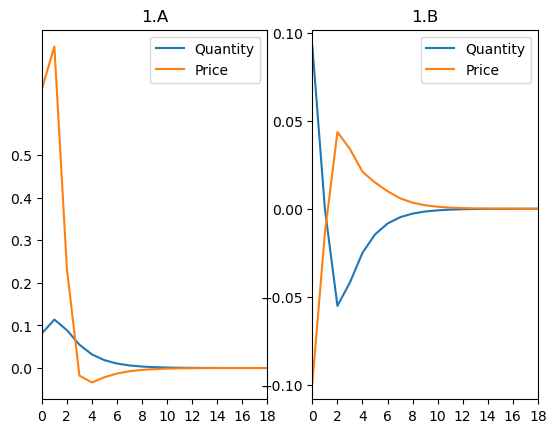

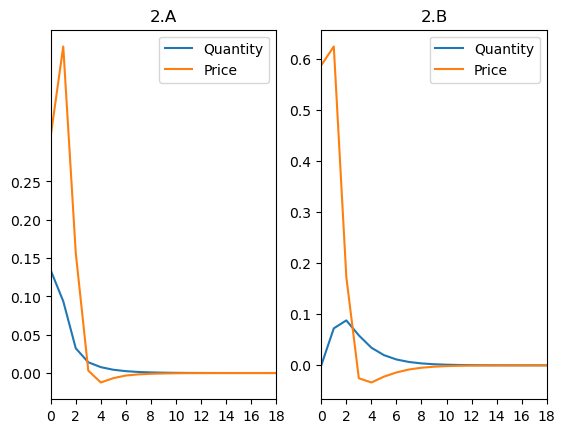

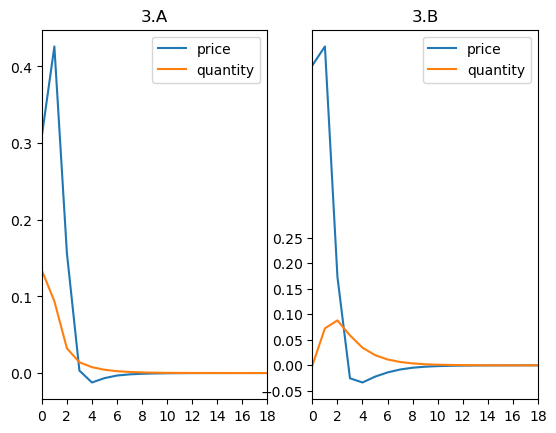

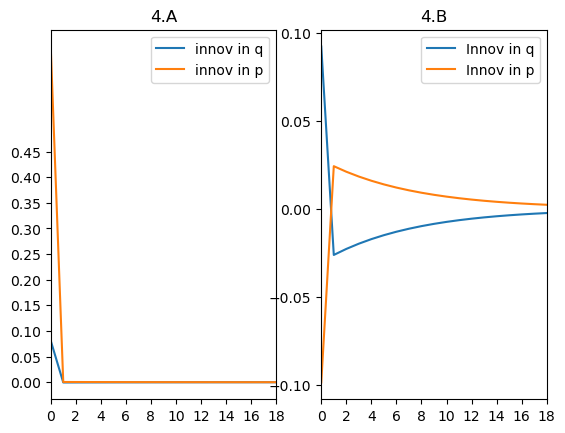

In [224]:
# Python version of twodiff1.m

import numpy as np
from scipy.linalg import companion
from scipy.signal import convolve
from scipy.linalg import cholesky


import quantecon as qe
from quantecon import DLE

import matplotlib.pyplot as plt
# Base Parameters
beta = 1/1.05
hd = 1
hs = 1
gs = 10
gd = 0.1
a2 = np.sqrt(1/(2*hs))
g = np.array([1, 0.8, 0.6, 0.4, 0.2])
lam1 = 0.6
lam2 = 0.4
lam3 = 0.2
mu1 = -0.8
mu2 = 0.4
mu3 = 0.2
bd1 = np.array([1, lam1])
bd2 = np.array([1, lam2])
bd3 = np.array([1, lam3])
bs1 = np.array([1, mu1])
bs2 = np.array([1, mu2])
bs3 = np.array([1, mu3])

deltak = 1
thetak = 1

Deltah = companion(np.array([1, 0, 0, 0, 0]))
Thetah = np.array([1, 0, 0, 0], dtype=float)[:,np.newaxis]
Gamma = np.array([1, 0, 0], dtype=float)[:,np.newaxis]

A22 = np.block([[companion(np.array([1, 0, 0, 0, 0])), np.zeros((4, 4))],
                [np.zeros((4, 4)), companion(np.array([1, 0, 0, 0, 0]))]])
C2 = np.array([[1, 0], [0, 0], [0, 0], [0, 0], [0, 1], [0, 0], [0, 0], [0, 0]], dtype=float)


var1 = 0.5  # supply shock variance
var2 = 4    # demand shock variance

shock1 = np.array([[np.sqrt(var1)], [0]])
shock2 = np.array([[0], [np.sqrt(var2)]])

shocks = [shock1, shock2]

C2new = C2@shocks
C2t = np.reshape(C2new,(2,8))
C2 = C2t.T

# Derived Parameters
f1 = np.sqrt(gd)
f2 = np.sqrt(hd)
f4 = -1/np.sqrt(hd)
f5 = np.sqrt(hs)
f6 = 1/np.sqrt(hs)
f7 = np.sqrt(gs)

Lambda = np.vstack([np.zeros(4), f1 * g[1:]])

Phic = np.array([1, -f5, 0])[:, np.newaxis]
Phii = np.array([-1, 0, -f7])[:, np.newaxis]
Phig = np.array([[0, 0],[1, 0],[0, 1]], dtype=float)

Pih = np.array([f2, f1*g[0]])[:,np.newaxis]

bb = convolve(bs1, bs2)
bs = convolve(bs3, bb)
bb = convolve(bd1, bd2)
bd = convolve(bb, bd3)

Ud = np.vstack([np.zeros(8), np.append(np.zeros(4), bs/f4), np.zeros(8)])
Ub = np.vstack([np.append(bd/f6, np.zeros(4)), np.zeros(8)])

beta = np.array([[beta]])
deltak = np.array([[deltak]])
thetak = np.array([[thetak]])

info = (A22, C2, Ub, Ud)
tech = (Phic, Phig, Phii, Gamma, deltak, thetak)
pref = (beta, Lambda, Pih, Deltah, Thetah)
econ = DLE(info, tech, pref)

# Figure 1
G = np.vstack([econ.Sc, econ.Mc])
C = econ.C
A0 = econ.A0

T = 18


irf_a = np.zeros((T+1, 2))
irf_b = np.zeros((T+1, 2))

for t in np.arange(T+1):
    irf_a[t, :] = (G@np.linalg.matrix_power(A0, t)@C)[:,0]
    irf_b[t, :] = (G@np.linalg.matrix_power(A0, t)@C)[:,1]

fig, ax = plt.subplots(1, 2)
handles = ax[0].plot(irf_a)
ax[0].set_title("1.A")
ax[0].set_xticks(np.arange(0, 20, 2))
ax[0].set_yticks(np.arange(-0.1, 0.6, 0.1))
ax[0].margins(x=0, y=0.05)
ax[0].legend(handles, ["Quantity", "Price"])

handles = ax[1].plot(irf_b)
ax[1].set_title("1.B")
ax[1].set_xticks(np.arange(0, 20, 2))
ax[1].set_yticks(np.arange(-0.25, 0.25, 0.05))
ax[1].margins(x=0, y=0.05)
ax[1].legend(handles, ["Quantity", "Price"])
fig.show()




# Figure 2
G = np.vstack([econ.Sc, econ.Mc])
H = 1e-8 * np.eye(2)
lss = qe.LinearStateSpace(A0, C, G, H)

hs_kal = qe.Kalman(lss)
w_lss = hs_kal.whitener_lss()
ma_coefs = hs_kal.stationary_coefficients(T+1, "ma")
cov = hs_kal.stationary_innovation_covar()

irf_a = np.zeros((T+1, 2))
irf_b = np.zeros((T+1, 2))

#Tom's additions here
L = np.linalg.cholesky(cov)
ma_coefs2 = ma_coefs@L

for t in range(T+1):
    irf_a[t, :] = ma_coefs2[t][:, 0] 
    irf_b[t, :] = ma_coefs2[t][:, 1] 

fig, ax = plt.subplots(1, 2)
handles = ax[0].plot(irf_a)
ax[0].set_title("2.A")
ax[0].set_xticks(np.arange(0, 20, 2))
ax[0].set_yticks(np.arange(-0.05, 0.3, 0.05))
ax[0].margins(x=0, y=0.05)
ax[0].legend(handles, ["Quantity", "Price"])

handles = ax[1].plot(irf_b)
ax[1].set_title("2.B")
ax[1].set_xticks(np.arange(0, 20, 2))
ax[1].set_yticks(np.arange(-0.1, 0.7, 0.1))
ax[1].margins(x=0, y=0.05)
ax[1].legend(handles, ["Quantity", "Price"])
fig.show()

# Figure 3
G = np.vstack([econ.Mc, econ.Sc])
H = 1e-8 * np.eye(2)
lss = qe.LinearStateSpace(A0, C, G, H)

hs_kal = qe.Kalman(lss)
w_lss = hs_kal.whitener_lss()
ma_coefs = hs_kal.stationary_coefficients(T+1, "ma")
cov = hs_kal.stationary_innovation_covar()

irf_a = np.zeros((T+1, 2))
irf_b = np.zeros((T+1, 2))


f = np.array([[0, 1],[1,0]])
finv =np.linalg.inv(f)
covf = f@cov@f.T
S = cholesky(covf, lower=True)

finv@S@S.T@finv.T
ma_coefs3 = ma_coefs@finv@S

for t in range(T+1):
    irf_a[t, :] = ma_coefs3[t][:, 0] 
    irf_b[t, :] = ma_coefs3[t][:, 1] 

fig, ax = plt.subplots(1, 2)
handles = ax[0].plot(irf_a)
ax[0].set_title("3.A")
ax[0].set_xticks(np.arange(0, 20, 2))
ax[0].set_yticks(np.arange(-0.1, 0.7, 0.1))
ax[0].margins(x=0, y=0.05)
ax[0].legend(handles, ["price", "quantity"])

handles = ax[1].plot(irf_b)
ax[1].set_title("3.B")
ax[1].set_xticks(np.arange(0, 20, 2))
ax[1].set_yticks(np.arange(-0.05, 0.3, 0.05))
ax[1].margins(x=0, y=0.05)
ax[1].legend(handles, ["price", "quantity"])
fig.show()

# Figure 4
G = np.vstack([econ.Sc, econ.Mc])
H = 1e-8 * np.eye(2)
lss = qe.LinearStateSpace(A0, C, G, H)

hs_kal = qe.Kalman(lss)
w_lss = hs_kal.whitener_lss()
ma_coefs = hs_kal.stationary_coefficients(T+1, "ma")
cov = hs_kal.stationary_innovation_covar()
whitener_irf = w_lss.impulse_response(T)[1]

irf_a = np.zeros((T+1, 2))
irf_b = np.zeros((T+1, 2))

for t in range(T+1):
    irf_a[t, :] = whitener_irf[t][:, 0] 
    irf_b[t, :] = whitener_irf[t][:, 1] 

fig, ax = plt.subplots(1, 2)
handles = ax[0].plot(irf_a)
ax[0].set_title("4.A")
ax[0].set_xticks(np.arange(0, 20, 2))
ax[0].set_yticks(np.arange(-0.05, 0.5, 0.05))
ax[0].margins(x=0, y=0.05)
ax[0].legend(handles, ["innov in q", "innov in p"])

handles = ax[1].plot(irf_b)
ax[1].set_title("4.B")
ax[1].set_xticks(np.arange(0, 20, 2))
ax[1].set_yticks(np.arange(-0.25, 0.25, 0.05))
ax[1].margins(x=0, y=0.05)
ax[1].legend(handles, ["Innov in q", "Innov in p"])
#fig.text(.5, .0001, "text to describe", ha='center')
fig.show()

In [225]:
# Some followup calculations by Tom Aug 12, 2023


# Just some scratchwork

# covariance matrix of shocks to price and quantity
covo = G@C@C.T@G.T
print('G C C.T G.T = ' , covo)

G C C.T G.T =  [[0.01509881 0.04401756]
 [0.04401756 0.43866002]]


In [226]:
# print 3 shock covariance matrices

covo, cov, covf

(array([[0.01509881, 0.04401756],
        [0.04401756, 0.43866002]]),
 array([[0.01793335, 0.04140731],
        [0.04140731, 0.44106373]]),
 array([[0.01793335, 0.04140731],
        [0.04140731, 0.44106373]]))

In [227]:
f, np.linalg.inv(f)

(array([[0, 1],
        [1, 0]]),
 array([[0., 1.],
        [1., 0.]]))